# 03 · Validation (Task 3)

> This notebook runs the same steps as `src/validate.py`, one cell at a time, with explanations and intermediate results. Both use the shared code in `src/salary/`, so the numbers are identical.

**Question:** how well does the classifier work on an applicant it has never seen, and where
does it fail?

1. Setup: why we split by person
2. Model comparison: keyword baseline, ablations, gradient boosting (5-fold CV repeated 5×)
3. Final model in detail: confidence interval, PR curve, confusion matrix
4. The business level: is each person's monthly income right?
5. Slices and errors
6. Threshold choice
7. Feature importance on held-out data
8. Stress test: worse bank text than in training
9. Conclusions

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from salary.data import load_transactions
from salary.style import COLORS, save, setup

setup()
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)
REPORTS = ROOT / "reports"
FIG = REPORTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def rounded(df, n=2):
    # Round numeric columns only (dates stay as they are).
    return df.round({c: n for c in df.select_dtypes("number").columns})

In [2]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.model_selection import StratifiedGroupKFold

from salary.evaluate import (bootstrap_ci, damage_text, income_metrics, oof_predict,
                             person_income, text_slice, txn_metrics)
from salary.features import FEATURE_COLS, PATTERN_COLS, TEXT_COLS, build_features
from salary.model import THRESHOLD, fit, make_gbm, make_logreg, rule_baseline

txns = load_transactions()
X = build_features(txns).reset_index(drop=True)
y = X.is_salary.to_numpy()
print(f"{len(X):,} credits, {y.sum()} salaries, {X.person_id.nunique()} persons")

2,093 credits, 876 salaries, 100 persons


## 1. Setup: split by person, not by transaction

A new applicant is a **new person**. If we split by transaction, the model sees the same
person's other salaries, employer and payday during training. That leaks, and the score is too
optimistic. We use `StratifiedGroupKFold(groups=person_id)`: every score below comes from
persons the model has never seen. We repeat 5-fold CV with **5 different shuffles** to see how
much the result depends on the split.

In [3]:
# Sanity check: no person appears in both train and test
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
for k, (tr, te) in enumerate(cv.split(X, y, groups=X.person_id)):
    overlap = set(X.person_id.iloc[tr]) & set(X.person_id.iloc[te])
    print(f"fold {k}: {X.person_id.iloc[te].nunique():>2} test persons, "
          f"{y[te].sum():>3} test salaries, overlap with train: {len(overlap)}")

fold 0: 20 test persons, 174 test salaries, overlap with train: 0
fold 1: 19 test persons, 178 test salaries, overlap with train: 0
fold 2: 22 test persons, 176 test salaries, overlap with train: 0
fold 3: 19 test persons, 171 test salaries, overlap with train: 0
fold 4: 20 test persons, 177 test salaries, overlap with train: 0


## 2. Model comparison

- **Keyword rule:** "lön/salary" in the text, and not Swish or an own transfer. This is what a
  first production version might do.
- **Ablations:** the final model with text features only, and with pattern features only.
- **Gradient boosting:** a more flexible model on the same features.

In [4]:
variants = {
    "LogReg, text + pattern (final)": (make_logreg, FEATURE_COLS),
    "LogReg, text only": (make_logreg, TEXT_COLS),
    "LogReg, pattern only": (make_logreg, PATTERN_COLS),
    "Gradient boosting, text + pattern": (make_gbm, FEATURE_COLS),
}
N_REPEATS = 5
rule = rule_baseline(X)
rows = [{"model": "Keyword rule", "repeat": 0, **txn_metrics(y, rule)}]
oof = {}
for name, (factory, cols) in variants.items():
    oof[name] = [oof_predict(factory, X, cols, seed=r) for r in range(N_REPEATS)]
    rows += [{"model": name, "repeat": r, **txn_metrics(y, p)} for r, p in enumerate(oof[name])]

res = pd.DataFrame(rows)
summary = res.drop(columns="repeat").groupby("model", sort=False).agg(["mean", "min", "max"])
summary.to_csv(REPORTS / "validation_models.csv")
summary[["precision", "recall", "f1", "pr_auc"]].xs("mean", axis=1, level=1).round(3).assign(
    f1_range=summary["f1"].apply(lambda r: f"{r['min']:.3f}–{r['max']:.3f}", axis=1))

,precision,recall,f1,pr_auc,f1_range
model,,,,,
Keyword rule,0.976,0.647,0.778,0.779,0.778–0.778
"LogReg, text + pattern (final)",0.995,0.998,0.996,1.000,0.996–0.997
"LogReg, text only",0.945,0.999,0.971,0.988,0.971–0.972
"LogReg, pattern only",0.934,0.971,0.952,0.989,0.949–0.956
"Gradient boosting, text + pattern",0.979,0.987,0.983,0.998,0.981–0.986


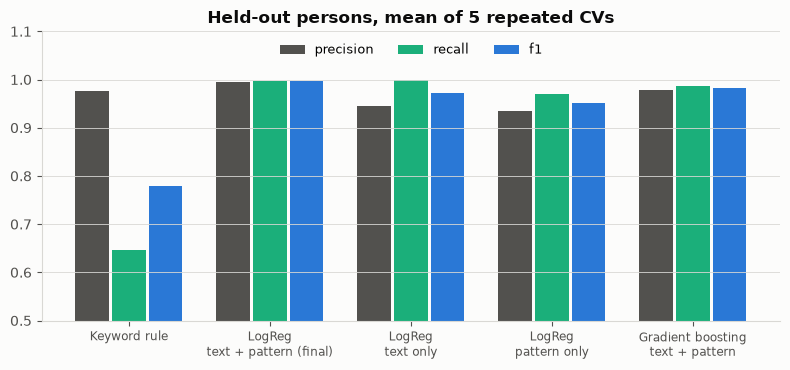

In [5]:
m = res.groupby("model", sort=False)[["precision", "recall", "f1"]].mean()
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(m))
for i, (col, color) in enumerate([("precision", COLORS["muted"]), ("recall", COLORS["aqua"]), ("f1", COLORS["blue"])]):
    ax.bar(x + (i - 1) * 0.26, m[col], width=0.24, color=color, label=col)
ax.set_xticks(x, [s.replace(", ", "\n") for s in m.index], fontsize=8.5)
ax.set(ylim=(0.5, 1.1), title="Held-out persons, mean of 5 repeated CVs")
ax.legend(frameon=False, ncol=3, loc="upper center")
ax.grid(axis="x", visible=False)
save(fig, FIG / "model_comparison.png")

- The **keyword rule** is precise but misses **35%** of salaries (empty text, employer name only).
- **Text only** has high recall but lets through private "lön" transfers (precision 0.945).
- **Pattern only** confuses salary with monthly benefits (precision 0.934).
- **Together** they reach F1 0.996, because each covers the other's weak spot (notebook 01).
- **Gradient boosting** is worse than the simple logistic regression, so we keep the simple model.
- The result barely depends on the split: F1 varies by less than 0.001 across the 5 repeats.

## 3. Final model in detail (repeat 0)

In [6]:
MAIN = "LogReg, text + pattern (final)"
p = oof[MAIN][0]
pred = p >= THRESHOLD
ci = bootstrap_ci(X, p)   # resample *persons*: persons are what varies between applicants
display(pd.DataFrame(ci, index=["95% CI low", "95% CI high"]).round(3))

cm = pd.DataFrame(confusion_matrix(y, pred), index=["true: not salary", "true: salary"],
                  columns=["pred: not salary", "pred: salary"])
cm

,precision,recall,f1
95% CI low,0.989,0.994,0.993
95% CI high,1.000,1.000,0.999


,pred: not salary,pred: salary
true: not salary,1213,4
true: salary,2,874


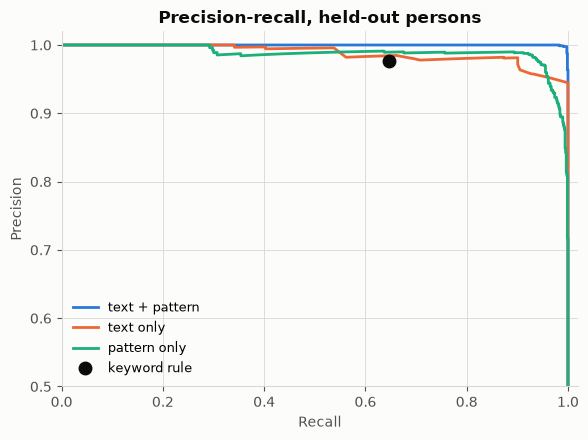

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for name, color in [(MAIN, COLORS["blue"]), ("LogReg, text only", COLORS["orange"]),
                    ("LogReg, pattern only", COLORS["aqua"])]:
    prec, rec, _ = precision_recall_curve(y, oof[name][0])
    ax.plot(rec, prec, color=color, lw=2, label=name.replace("LogReg, ", "").replace(" (final)", ""))
r = txn_metrics(y, rule)
ax.plot(r["recall"], r["precision"], "o", ms=9, color=COLORS["ink"], label="keyword rule")
ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1.02), ylim=(0.5, 1.02),
       title="Precision-recall, held-out persons")
ax.legend(loc="lower left", frameon=False)
save(fig, FIG / "pr_curves.png")

## 4. The business level: is each person's income right?

Kreditz needs the applicant's **income**, not a list of transactions. For each person:
average monthly salary = sum of salary ÷ months with any data. So a person who joined in
August is not divided by 12.

In [8]:
per = person_income(X, pred, txns)
per_rule = person_income(X, rule >= THRESHOLD, txns)
per.to_csv(REPORTS / "validation_person_income.csv")
inc, inc_rule = income_metrics(per), income_metrics(per_rule)
pd.DataFrame({"model": inc, "keyword rule": inc_rule}).round(3)

,model,keyword rule
person_has_salary_acc,0.990,0.850
no_salary_persons_with_false_income,1.000,1.000
income_median_abs_pct_err,0.000,0.084
income_share_within_5pct,0.942,0.406
income_share_within_10pct,0.971,0.522


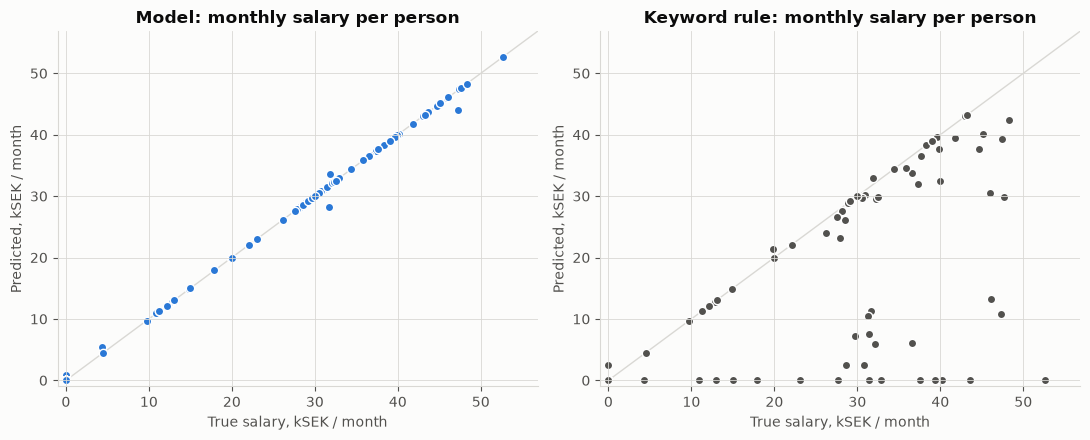

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, d, title in [(axes[0], per, "Model"), (axes[1], per_rule, "Keyword rule")]:
    k = d[["true_monthly", "pred_monthly"]] / 1000
    lim = per.true_monthly.max() / 1000 * 1.08
    ax.plot([0, lim], [0, lim], color=COLORS["grid"], lw=1, zorder=0)
    ax.scatter(k.true_monthly, k.pred_monthly, s=36, edgecolor="white",
               color=COLORS["blue"] if title == "Model" else COLORS["muted"])
    ax.set(xlabel="True salary, kSEK / month", ylabel="Predicted, kSEK / month",
           xlim=(-1, lim), ylim=(-1, lim), title=f"{title}: monthly salary per person")
save(fig, FIG / "income_scatter.png")

In [10]:
# Persons whose income is off by more than 1%, or who get income without having a salary
per[(per.abs_pct_err > 0.01) | (~per.has_salary & per.pred_has_salary)][
    ["months", "true_monthly", "pred_monthly", "abs_pct_err"]].round(3)

,months,true_monthly,pred_monthly,abs_pct_err
person_id,,,,
P002,12,31846.709,33569.951,0.054
P011,5,31684.500,28218.730,0.109
P032,12,0.000,910.202,NaN
P040,12,4344.048,5440.381,0.252
P078,12,47256.974,44095.566,0.067


## 5. Slices and errors

In [11]:
X["slice"], X["proba"], X["pred"] = text_slice(X), p, pred
slices = X.groupby("slice").apply(lambda g: pd.Series({
    "credits": len(g), "salaries": int(g.is_salary.sum()),
    "recall": g.loc[g.is_salary, "pred"].mean() if g.is_salary.any() else np.nan,
    "false positives": int((g.pred & ~g.is_salary).sum()),
    "rule recall": rule[g.index][g.is_salary].mean() if g.is_salary.any() else np.nan,
    "rule false positives": int(((rule[g.index] == 1) & ~g.is_salary).sum()),
}), include_groups=False)
slices.to_csv(REPORTS / "validation_slices.csv")
slices.round(3)

,credits,salaries,recall,false positives,rule recall,rule false positives
slice,,,,,,
'lön' via Swish/transfer,41.0,0.0,NaN,0.0,NaN,0.0
corrupted text,14.0,11.0,1.000,0.0,0.818,1.0
employer name,181.0,181.0,0.994,0.0,0.000,0.0
empty text,120.0,84.0,1.000,1.0,0.000,0.0
other text,863.0,42.0,0.976,0.0,0.000,0.0
pension/CSN/benefit,303.0,0.0,NaN,0.0,NaN,0.0
salary keyword,571.0,558.0,1.000,3.0,1.000,13.0


In [12]:
# Persons with short coverage (< 11 months) vs. full year
short = per.index[per.months < 11]
in_short = X.person_id.isin(short).to_numpy()
coverage = {"short_coverage_persons": int(len(short)),
            "short": txn_metrics(y[in_short], p[in_short]),
            "full": txn_metrics(y[~in_short], p[~in_short])}
pd.DataFrame({"< 11 months": coverage["short"], "11–12 months": coverage["full"]}).round(3)

,< 11 months,11–12 months
precision,1.000,0.995
recall,0.986,0.999
f1,0.993,0.997
pr_auc,1.000,1.000
fp,0.000,4.000
fn,1.000,1.000


In [13]:
errors = X.loc[pred != y, ["person_id", "date", "amount", "text", "is_salary", "proba", "slice",
                           "recur_loose_months", "key_n_months"]].sort_values("proba")
errors.to_csv(REPORTS / "validation_errors.csv", index=False)
rounded(errors, 3)

,person_id,date,amount,text,is_salary,proba,slice,recur_loose_months,key_n_months
1591,P078,2025-12-19,37936.90,NORDIC TRANSPO,True,0.031,other text,0,1
217,P011,2025-12-19,17328.85,Sigma Media AB,True,0.185,employer name,0,1
721,P040,2025-01-24,13156.00,,False,0.622,empty text,9,1
38,P002,2025-09-14,11871.92,lön,False,0.637,salary keyword,0,11
589,P032,2025-02-28,10922.43,Lön ID:20250228-518,False,0.775,salary keyword,4,2
30,P002,2025-04-28,8806.98,Lön,False,0.883,salary keyword,1,11


The 6 errors are explainable:
- **Missed (2):** employer payments on **19 December**. They are off-cycle (probably a bonus)
  and there is no recurrence to learn from.
- **False (3):** private "Lön" transfers of salary-like size. P032 is unemployed.
- **False (1):** a **CSN** payment with **empty** text on the 25th. Without text it looks
  exactly like a salary.

## 6. Threshold choice
For a lender, **overstating** income (a false salary) is worse than understating it. A higher
threshold trades misses for fewer false salaries.

,threshold,precision,recall,f1,pr_auc,fp,fn
4,0.3,0.993,0.998,0.995,1.0,6,2
8,0.5,0.995,0.998,0.997,1.0,4,2
12,0.7,0.998,0.997,0.997,1.0,2,3
16,0.9,1.000,0.983,0.991,1.0,0,15


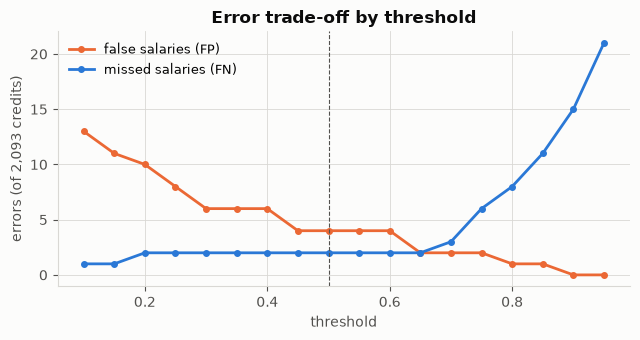

In [14]:
thr = pd.DataFrame([{"threshold": t, **txn_metrics(y, p, t)} for t in np.round(np.arange(0.1, 0.96, 0.05), 2)])
thr.to_csv(REPORTS / "validation_thresholds.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(thr.threshold, thr.fp, color=COLORS["orange"], lw=2, marker="o", ms=4, label="false salaries (FP)")
ax.plot(thr.threshold, thr.fn, color=COLORS["blue"], lw=2, marker="o", ms=4, label="missed salaries (FN)")
ax.axvline(THRESHOLD, color=COLORS["muted"], lw=0.8, ls="--")
ax.set(xlabel="threshold", ylabel="errors (of 2,093 credits)", title="Error trade-off by threshold")
ax.legend(frameon=False)
save(fig, FIG / "thresholds.png")
thr[thr.threshold.isin([0.3, 0.5, 0.7, 0.9])].round(3)

At 0.5 the model makes 4 false and 2 missed. At 0.7 it makes 2 false and 3 missed. I keep 0.5
(best F1). In production, the business cost of each error type should set the threshold.

## 7. Which features matter on held-out data?
Permutation importance: for each feature, how much does PR-AUC drop on the test fold when we
shuffle that feature? Averaged over the 5 folds.

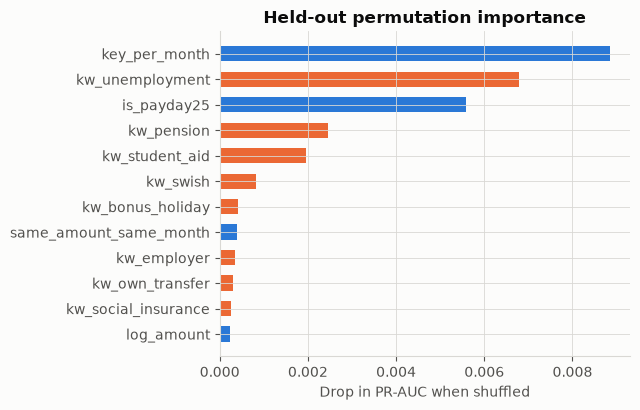

In [15]:
scores = []
for tr, te in StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0).split(X, y, groups=X.person_id):
    mdl = fit(make_logreg(), X.iloc[tr])
    r = permutation_importance(mdl, X.iloc[te][FEATURE_COLS], y[te].astype(int),
                               scoring="average_precision", n_repeats=10, random_state=0)
    scores.append(r.importances_mean)
imp = pd.Series(np.mean(scores, axis=0), index=FEATURE_COLS, name="pr_auc_drop").sort_values(ascending=False)
imp.to_csv(REPORTS / "validation_importance.csv")

top = imp.head(12)[::-1]
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.barh(top.index, top.values, height=0.6,
        color=[COLORS["orange"] if c in TEXT_COLS else COLORS["blue"] for c in top.index])
ax.set(xlabel="Drop in PR-AUC when shuffled", title="Held-out permutation importance")
save(fig, FIG / "importance.png")

Every single drop is small. That is because the evidence is **redundant**: if one recurrence
feature is shuffled, another one carries the same information. This is a good sign for
robustness. The features that matter most are payday, one payment per month from the same
payer, and the benefit keywords (a-kassa, pension, CSN), which rule out benefits that share
the rhythm.

## 8. Stress test: worse bank text than in training
We train on clean data and score held-out persons with damaged text. In the last row, a
pattern-only model is retrained on text-less data, as a fallback for banks that send no
text at all.

,precision,recall,f1,pr_auc,fp,fn,rule_recall
scenario,,,,,,,
clean,0.995,0.998,0.997,1.000,4,2,NaN
Swedish letters lost,0.994,0.998,0.996,1.000,5,2,0.647
texts cut to 8 chars,0.873,0.993,0.929,0.984,127,6,0.584
50% of texts blank,0.790,0.984,0.876,0.939,229,14,0.326
no text,0.495,0.999,0.662,0.836,892,1,0.000
"no text, retrained on pattern features",0.891,0.897,0.894,0.950,96,90,NaN


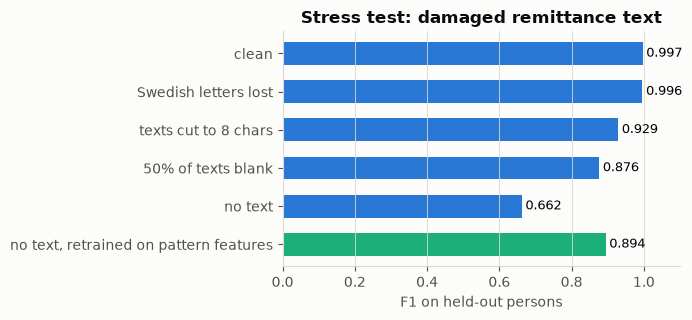

In [16]:
stress = [{"scenario": "clean", **txn_metrics(y, p)}]
for mode in ["Swedish letters lost", "texts cut to 8 chars", "50% of texts blank", "no text"]:
    X_bad = build_features(damage_text(txns, mode)).reset_index(drop=True)
    p_bad = oof_predict(make_logreg, X, FEATURE_COLS, seed=0, X_eval=X_bad)
    stress.append({"scenario": mode, **txn_metrics(y, p_bad),
                   "rule_recall": txn_metrics(y, rule_baseline(X_bad))["recall"]})
stress.append({"scenario": "no text, retrained on pattern features",
               **txn_metrics(y, oof_predict(make_logreg, X_bad, PATTERN_COLS, seed=0))})
stress = pd.DataFrame(stress).set_index("scenario")
stress.to_csv(REPORTS / "validation_stress.csv")

fig, ax = plt.subplots(figsize=(7, 3.3))
s = stress.f1[::-1]
ax.barh(s.index, s.values, height=0.6,
        color=[COLORS["aqua"] if "retrained" in i else COLORS["blue"] for i in s.index])
for i, v in enumerate(s.values):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
ax.set(xlim=(0, 1.1), xlabel="F1 on held-out persons", title="Stress test: damaged remittance text")
ax.grid(axis="y", visible=False)
save(fig, FIG / "stress_test.png")
stress.round(3)

- The model is robust to the damage it has seen in training, such as lost Swedish letters.
- It degrades when text quality falls far below that.
- With **no text at all**, a pattern-only model still reaches F1 ≈ 0.89. What remains is
  confusion with benefits, which have the same rhythm, and only text can fix that.

## 9. Conclusions

In [17]:
main_mean = res[res.model == MAIN][["precision", "recall", "f1", "pr_auc"]].mean()
summary_out = {
    "main_model": MAIN,
    "threshold": THRESHOLD,
    "cv": f"{N_REPEATS}x repeated 5-fold StratifiedGroupKFold by person_id",
    "txn_metrics_mean": main_mean.round(4).to_dict(),
    "txn_metrics_repeat0": txn_metrics(y, p),
    "bootstrap_95ci_by_person": ci,
    "income_model": inc,
    "income_rule_baseline": inc_rule,
    "coverage": coverage,
}
(REPORTS / "validation_summary.json").write_text(json.dumps(summary_out, indent=2, default=float))
pd.Series({
    "F1, mean of 5 repeats": f"{main_mean.f1:.3f}",
    "F1 95% CI (bootstrap over persons)": f"{ci['f1'][0]:.3f}–{ci['f1'][1]:.3f}",
    "Keyword rule F1": f"{txn_metrics(y, rule)['f1']:.3f}",
    "Errors (repeat 0)": f"{int((pred != y).sum())} of {len(y):,} credits",
    "Earners with income within 5%": f"{inc['income_share_within_5pct']:.0%} (rule: {inc_rule['income_share_within_5pct']:.0%})",
    "Persons correct salary / no salary": f"{inc['person_has_salary_acc']:.0%}",
}, name="result").to_frame()

,result
"F1, mean of 5 repeats",0.996
F1 95% CI (bootstrap over persons),0.993–0.999
Keyword rule F1,0.778
Errors (repeat 0),"6 of 2,093 credits"
Earners with income within 5%,94% (rule: 41%)
Persons correct salary / no salary,99%


**Why the numbers are optimistic**
- The data is synthetic and cleaner than real bank data.
- The keyword groups were written after looking at all 100 persons, so the CV does not fully
  test how well they generalise to new text formats.
- There is only one year of data, so there is no out-of-time test.

**Next steps**
- Validate on real, human-labelled data, with an out-of-time split.
- Learn the text features (char n-grams) instead of hand-written lists.
- Use a counterparty ID if the bank provides one.
- Report income per person with a confidence score.
- Monitor the empty-text rate and the salary share per bank.